In [1]:
import glob
import h5py
import importlib
import IPython.display as ipd
import numpy as np
import os
import sys
from pathlib import Path
import pickle

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Look at difference in unit response pre and post gain 

## Main question of this analysis: Attention believed to sharpen unit tuning - can gains produce this effect without actually changing tuning of units?

### Proposed approach: Look at pre-gain and post-gain tuning of units in model. 

#### In brief: 
* Use example unit that is tuned to a given f0
* Plot response as function of voice F0
* Compare activations of mixture post gaining for different f0's within center of distribution




## Import saved activations for proof of concept  


Need to run this with independent cues, targets and distractors, where target and distractors are passed through the model without attention 

In [2]:
model = "word_task_v10_main_feature_gain_config"

analysis_dir = Path(f"binaural_unit_activation_analysis/{model}")
# get shape dict 
with open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb") as f:
    layer_shape_dict = pickle.load(f)

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg_diotic.h5"

h5 = h5py.File(h5_fn, "r") 
# print(h5.keys())
# for key in h5.keys():
#     print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

In [3]:
target_f0s

array([191.97675 , 101.6409  , 155.03363 , 127.53968 , 230.79468 ,
       144.20189 , 199.90587 , 100.028496, 204.09218 , 146.30466 ,
       265.26703 , 113.544075, 223.47194 , 106.937325, 128.5949  ,
       203.52728 , 122.492714, 205.61238 , 109.34371 , 191.36333 ,
       124.022575, 188.48318 , 179.18686 , 107.6708  , 170.44485 ,
       119.550125, 214.16261 , 123.75129 , 190.76392 , 158.11284 ,
        87.80316 , 203.58453 , 166.85173 , 157.98814 , 128.79584 ,
       192.64122 , 187.60895 , 138.61366 , 150.27144 , 169.08003 ,
       190.53735 , 103.48982 , 247.08476 , 133.1744  , 207.37997 ,
       113.12198 , 115.264   , 200.6778  , 130.35509 , 165.239   ,
       149.5678  , 194.27798 , 201.83725 , 122.25385 , 121.9816  ,
       162.339   , 177.39471 , 131.06403 ,  90.54141 , 184.36107 ,
       111.72892 , 175.53831 , 210.50293 , 130.8314  , 196.0489  ,
       150.43103 , 231.18411 , 130.0463  , 130.14224 , 242.13011 ,
       226.57333 , 104.8727  , 112.703545, 165.6001  , 229.783

In [4]:
# min_f0 = target_f0s.min()
# max_f0 = target_f0s.max()

# # got log-spaced bins between min and max f0 
# n_bins = 20

# hist_bins = np.logspace(np.log10(min_f0), np.log10(max_f0+1), n_bins)

# outs = plt.hist(target_f0s, bins=hist_bins)
# counts, bins = outs[0], outs[1]
# # print(len(counts), len(bins))
# f0_assignments = np.digitize(target_f0s, bins, right=True)
# bins = bins.round(0)
# f0_bins = bins[f0_assignments]
# f0_bins = f0_bins.astype(int)

# # group like with locations 
# f0_ixs = {}
# for f0 in np.unique(f0_bins):
#     f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

# unique_locs = np.unique(target_locs, axis=0)
# unique_f0s = np.unique(f0_bins)

# unique_features = list(unique_locs) + list(unique_f0s)
# # isinstance(unique_features[-1], int)
# unique_features

### proof of concept: get average gains for each location

In [5]:
h5.keys()

<KeysViewHDF5 ['attn0_diff_sex_dist', 'attn0_diff_sex_dist_mixture_diff_corr', 'attn0_mixture_diff', 'attn0_mixture_nat_scene', 'attn0_mixture_same', 'attn0_nat_scene_dist', 'attn0_nat_scene_dist_mixture_nat_scene_corr', 'attn0_same_sex_dist', 'attn0_same_sex_dist_mixture_same_corr', 'attn0_target', 'attn0_target_mixture_diff_corr', 'attn0_target_mixture_nat_scene_corr', 'attn0_target_mixture_same_corr', 'attn1_diff_sex_dist', 'attn1_diff_sex_dist_mixture_diff_corr', 'attn1_gains', 'attn1_mixture_diff', 'attn1_mixture_nat_scene', 'attn1_mixture_same', 'attn1_nat_scene_dist', 'attn1_nat_scene_dist_mixture_nat_scene_corr', 'attn1_same_sex_dist', 'attn1_same_sex_dist_mixture_same_corr', 'attn1_target', 'attn1_target_mixture_diff_corr', 'attn1_target_mixture_nat_scene_corr', 'attn1_target_mixture_same_corr', 'attn2_diff_sex_dist', 'attn2_diff_sex_dist_mixture_diff_corr', 'attn2_gains', 'attn2_mixture_diff', 'attn2_mixture_nat_scene', 'attn2_mixture_same', 'attn2_nat_scene_dist', 'attn2_nat

In [6]:
# attn_layers = [k for k in h5.keys() if 'gains' in k]

# fig, axs = plt.subplots(1, len(attn_layers), figsize=(21, 3))

# for ix, layer in enumerate(attn_layers):
#     gains = h5[layer][:]
#     gain_avg_dict = {}
#     for feature in unique_features:
#         if isinstance(feature, np.int64):
#             gain_ixs = (f0_bins == feature)
#         else:
#             gain_ixs = (target_locs == feature).all(axis=1)
#         if gain_ixs.sum() == 0:
#             continue
#         avg_gains = gains[gain_ixs].mean(0)
#         gain_avg_dict[str(feature)] = {'gains':avg_gains, 'feature':feature}

#     for key,vals in gain_avg_dict.items():
#         axs[ix].hist(vals['gains'], bins=20, alpha=0.5, )
#         axs[ix].set_title(layer)
# plt.tight_layout()

In [7]:
# f0_order

## Unit ids to check 

Layer 3 
- unit 616, 3676, 2356, 2806

In [8]:
def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min())

In [9]:
h5.keys()

<KeysViewHDF5 ['attn0_diff_sex_dist', 'attn0_diff_sex_dist_mixture_diff_corr', 'attn0_mixture_diff', 'attn0_mixture_nat_scene', 'attn0_mixture_same', 'attn0_nat_scene_dist', 'attn0_nat_scene_dist_mixture_nat_scene_corr', 'attn0_same_sex_dist', 'attn0_same_sex_dist_mixture_same_corr', 'attn0_target', 'attn0_target_mixture_diff_corr', 'attn0_target_mixture_nat_scene_corr', 'attn0_target_mixture_same_corr', 'attn1_diff_sex_dist', 'attn1_diff_sex_dist_mixture_diff_corr', 'attn1_gains', 'attn1_mixture_diff', 'attn1_mixture_nat_scene', 'attn1_mixture_same', 'attn1_nat_scene_dist', 'attn1_nat_scene_dist_mixture_nat_scene_corr', 'attn1_same_sex_dist', 'attn1_same_sex_dist_mixture_same_corr', 'attn1_target', 'attn1_target_mixture_diff_corr', 'attn1_target_mixture_nat_scene_corr', 'attn1_target_mixture_same_corr', 'attn2_diff_sex_dist', 'attn2_diff_sex_dist_mixture_diff_corr', 'attn2_gains', 'attn2_mixture_diff', 'attn2_mixture_nat_scene', 'attn2_mixture_same', 'attn2_nat_scene_dist', 'attn2_nat

Text(0.5, 1.0, 'Unit 2806, Max F0: 130.83 Hz')

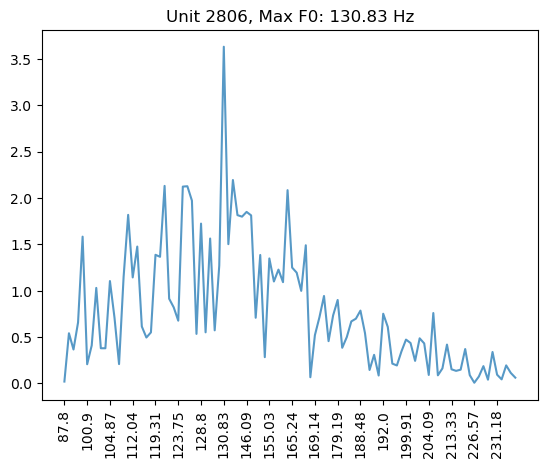

In [48]:
### Look at layer 2 as eg 

layer_ix = 3 # is 4th layer with 0 ix 
if layer_ix == 6:
    gain_key = "attnfc"
else:
    gain_key = f"attn{layer_ix+1}"
    
sex_cond = 'same'
n_units = h5[f"hann_pool_{layer_ix}_target"].shape[1]

# randomly plot n units 
n_to_plot = 1
# unit_ix = np.random.choice(n_units, n_to_plot, replace=False) 
# unit_ix = np.random.randint(n_units) 

f0_order = target_f0s.argsort()
f0_labels = target_f0s[f0_order]
# n_cols = 5
# n_rows = n_to_plot // n_cols

# fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 10))
# axs = axs.ravel()
# for ix, unit_ix in enumerate(unit_ixs):
unit_ix = 2806 # 616, 3676, 2356, 2806


acts = h5[f"hann_pool_{layer_ix}_target"][:]
unit = acts[:,unit_ix]
ordered = unit[f0_order]
plt.plot(ordered, alpha=0.75)

f0_tol = .05 # within 5% of max tuning
max_ix = ordered.argmax()
max_tuning = f0_labels[max_ix]
min_bound = max_tuning - (max_tuning * f0_tol)
max_bound = max_tuning + (max_tuning * f0_tol) 

# wanted_ixs = np.where((target_f0s >= min_bound) & (target_f0s <= max_bound))[0]

# gain_set = h5[f'attn{layer_ix+1}_gains'][sorted(wanted_ixs) , unit_ix]

# scaled_acts = minmax_norm((ordered * gain_set.reshape(-1, 1)).mean(0))
# plt.plot(h5[f"{gain_key}_target"][:, unit_ix][f0_order])
# plt.plot(scaled_acts, alpha=0.75) 


plt.xticks(np.arange(len(f0_labels), step=5), f0_labels.round(2)[::5], rotation=90);

plt.title(f"Unit {unit_ix}, Max F0: {max_tuning:.2f} Hz")



In [13]:
### Need to get gain for unit, when attending to other f0 



(100,)

In [129]:

# gain_set = h5[f'attn{layer_ix+1}_gains'][sorted(wanted_ixs),:]
# for gains in gain_set:
#     gained = acts * gains
#     plt.plot(minmax_norm(gained[f0_order,unit_ix]))
# plt.plot(minmax_norm(ordered), 'k')


(100, 5120)

In [45]:
max_tuning - (max_tuning *.1)

109.78343811035157

In [23]:
gain_set.shape

(100,)

In [49]:
def zscore(x):
    return (x - x.mean()) / x.std() 

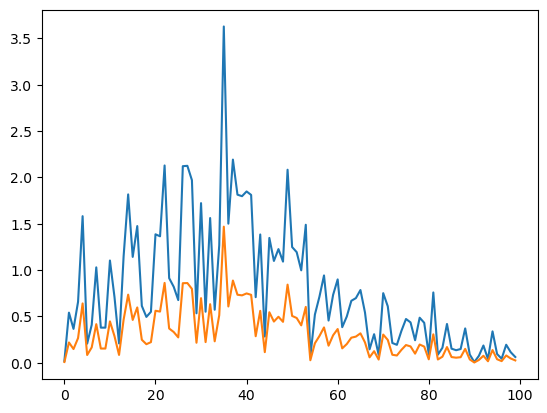

In [59]:
### Get gains at layer 
layer_ix = 3 # is 4th layer with 0 ix

f0_tol = .1 # within 10% of max tuning
min_bound = max_tuning - (max_tuning * f0_tol)
max_bound = max_tuning + (max_tuning * f0_tol) 

wanted_ixs = np.where((target_f0s >= min_bound) & (target_f0s <= max_bound))[0]

gain_set = h5[f'attn{layer_ix+1}_gains'][: , unit_ix][f0_order]

# mixture_post_attn = h5[f"{gain_key}_mixture_{sex_cond}"][sorted(wanted_ixs) , unit_ix]


scaled_acts = ordered * gain_set.reshape(-1, 1)
plt.plot(ordered)
plt.plot(scaled_acts.mean(0))
# mean_attenuated = 
# for ix, gain in enumerate(gain_set):
#     print(f"{f0_labels[wanted_ixs][ix]:.2f} Hz: {gain:.2f}")
    # to_plot = ordered * gain
    # plt.plot(to_plot)


array([0.10125   , 0.8851376 , 0.94066054, 0.7449881 , 0.15415815,
       0.66744775, 0.9098733 , 0.9362514 , 0.26760665, 0.72485465,
       0.41798472, 0.6799844 , 0.10015189, 0.23348765, 0.94143623,
       0.46410793, 0.83313715, 0.84044874, 0.9507201 , 0.99648696,
       0.27665275, 0.9983737 , 0.7974991 , 0.8020958 , 0.593512  ,
       0.81388295, 0.55358225, 0.11132784, 0.14682187, 0.97192985,
       0.5570905 , 0.21729675, 0.33554333, 0.48419878, 0.11187045,
       0.13919823, 0.9596801 , 0.06108235, 0.38104403, 0.09882022,
       0.43767387, 0.9724389 , 0.2389164 , 0.09946801, 0.287707  ,
       0.10914246, 0.19741163, 0.06680397, 0.02805226, 0.05314939,
       0.02853329, 0.05627158, 0.0352339 , 0.06244041, 0.02934021,
       0.84381294, 0.90721047, 0.0330941 , 0.03011558, 0.11297671,
       0.02637649, 0.02612513, 0.03956678, 0.03099648, 0.03762636,
       0.02415795, 0.02484469, 0.02417287, 0.04022437, 0.03602738,
       0.1406667 , 0.05790742, 0.0300644 , 0.04596964, 0.03791

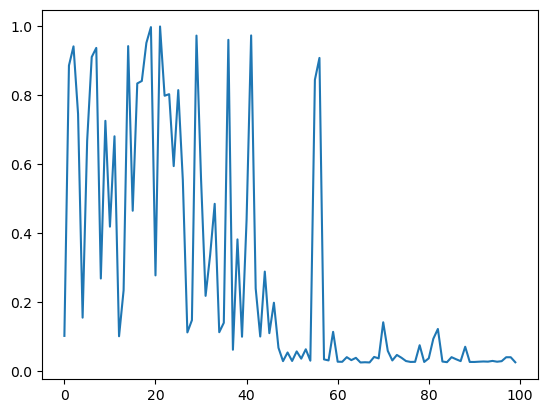

In [19]:


plt.plot(h5[f'attn{layer_ix+1}_gains'][:, unit_ix][f0_order])


In [36]:
target_f0s[target_f0s.argsort()]


array([ 87.80316 ,  90.54141 ,  98.937164,  99.78336 , 100.028496,
       100.901566, 101.6409  , 103.48982 , 104.29693 , 104.678085,
       104.8727  , 106.937325, 107.6708  , 109.34371 , 111.72892 ,
       112.04441 , 112.703545, 113.12198 , 113.544075, 115.264   ,
       119.308624, 119.550125, 121.9816  , 122.25385 , 122.492714,
       123.75129 , 124.022575, 127.438805, 127.53968 , 128.5949  ,
       128.79584 , 129.97815 , 130.0463  , 130.14224 , 130.35509 ,
       130.8314  , 131.06403 , 133.1744  , 138.61366 , 144.20189 ,
       146.08896 , 146.30466 , 149.5678  , 150.27144 , 150.43103 ,
       155.03363 , 157.98814 , 158.11284 , 162.339   , 163.01045 ,
       165.239   , 165.6001  , 165.7368  , 166.85173 , 169.08003 ,
       169.14145 , 170.44485 , 175.07622 , 175.53831 , 177.39471 ,
       179.18686 , 181.78664 , 184.36107 , 184.63554 , 187.60895 ,
       188.48318 , 190.53735 , 190.76392 , 191.36333 , 191.97675 ,
       191.99986 , 192.64122 , 194.27798 , 196.0489  , 197.503